# Gravitational-Wave Turbulence Spectra Explorer

Based on the BK2016 self-similar scaling $E(k\xi(t),t) = \xi^{-\beta}\,\phi(k\xi)$ with $\xi \propto t^q$.

## Piecewise spectrum
$$
E(k,t_0)=
\begin{cases}
C\, k^{s}, & k < k_0(t) \\
C'\, k^{-5/3}, & k > k_0(t)
\end{cases}
$$

**First constant**: $C = 1$.  
**Second constant**: continuity at $k_0$ forces $C \cdot k_0^s = C' \cdot k_0^{-5/3}$, so
$$C' = k_0(t)^{\,s + 5/3}.$$

## Peak wavenumber evolution
| $\beta$ | $q$ | $p$ | $k_0(t)$ |
|---------|-----|-----|----------|
| 4 | 2/7 | 10/7 | $k_0(t_0)\left(1+t/t_1\right)^{-2/7}$ |
| 1 | 1/2 | 1   | $k_0(t_0)\left(1+t/t_1\right)^{-1/2}$ |
| 0 | 2/3 | 2/3 | $k_0(t_0)\left(1+t/t_1\right)^{-2/3}$ |

Total energy decays as $\mathcal{E}(t)\propto(1+t/t_1)^{-p}$.  
The **coloured trail** shows the locus of the spectral peak $(k_0(t'),\,E_{\rm peak}(t'))$ from $t'=0$ to the current $t$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatLogSlider, FloatSlider, Dropdown, fixed
from IPython.display import display

%matplotlib widget
plt.rcParams.update({'figure.dpi': 100, 'font.size': 20})


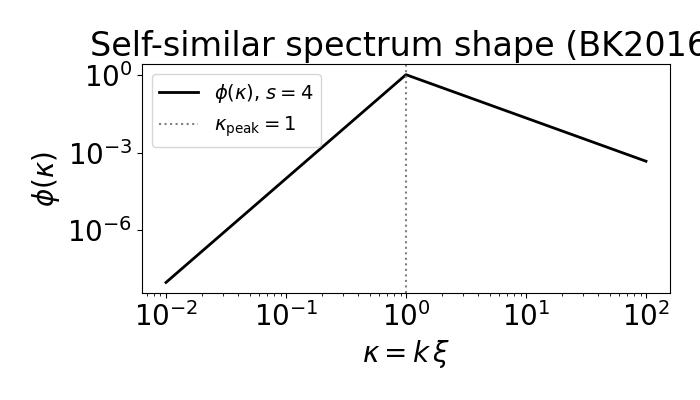

Continuity check at kappa=1: phi(1-)/phi(1+) = 0.994639


In [2]:
# ── Spectrum helper functions (BK2016 self-similar form) ──────────────────

def phi_spectrum(kappa, s=4, kappa_peak=1.0):
    """Self-similar shape  phi(kappa): k^s below peak, k^{-5/3} above (Kolmogorov).
    Continuity at kappa_peak:  C' = kappa_peak^{s + 5/3}.
    """
    kappa = np.asarray(kappa, dtype=float)
    C_prime = kappa_peak ** (s + 5 / 3)
    return np.where(kappa < kappa_peak, kappa**s, C_prime * kappa**(-5 / 3))


def xi_t(t, q, t1=1.0):
    """Normalised integral scale  xi(t)/xi(0) = (1 + t/t1)^q."""
    return (1.0 + t / t1) ** q


def E_spectrum(k, t, beta, q_exp, k0_init=1.0, t1=1.0, s=4):
    """BK2016 self-similar energy spectrum
       E(k,t) = xi(t)^{-beta}  phi(k * xi(t) / k0_init)
    Physical peak is at  k0(t) = k0_init / xi(t).
    """
    xi = xi_t(t, q_exp, t1)
    kappa = k * xi / k0_init
    return xi ** (-beta) * phi_spectrum(kappa, s=s, kappa_peak=1.0)


def k_peak_t(t, k0_init, q_exp, t1=1.0):
    """Peak wavenumber  k0(t) = k0_init * (1 + t/t1)^{-q}."""
    return k0_init / xi_t(t, q_exp, t1)


def E_at_peak(t, k0_init, beta, q_exp, t1=1.0, s=4):
    """Spectrum amplitude evaluated at the peak k0(t)."""
    kp = k_peak_t(t, k0_init, q_exp, t1)
    return E_spectrum(kp, t, beta, q_exp, k0_init, t1, s)


# ── Sanity check: phi should be continuous at kappa_peak ──────────────────
kappa_test = np.logspace(-2, 2, 2000)
phi_test   = phi_spectrum(kappa_test, s=4, kappa_peak=1.0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(kappa_test, phi_test, 'k-', lw=2, label=r'$\phi(\kappa)$, $s=4$')
ax.axvline(1.0, ls=':', color='gray', label=r'$\kappa_{\rm peak}=1$')
ax.set_xlabel(r'$\kappa = k\,\xi$')
ax.set_ylabel(r'$\phi(\kappa)$')
ax.set_title('Self-similar spectrum shape (BK2016)')
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()
print(f"Continuity check at kappa=1: phi(1-)/phi(1+) = {phi_test[999]/phi_test[1000]:.6f}")


## Decay classes (BK2016 Table I)

The three robust classes found from DNS, together with the scaling relations
$$\beta = \frac{2}{q}-3, \qquad p = (1+\beta)\,q, \qquad \text{self-similarity line: } p=2(1-q).$$

| Class | $\beta$ | $q$ | $p$ | Physical invariant |
|---|---|---|---|---|
| HD (Loitsiansky) | 4 | 2/7 ≈ 0.286 | 10/7 ≈ 1.43 | Loitsiansky integral $\mathcal{L}$ |
| HD (Saffman) | 3 | 1/3 ≈ 0.333 | 4/3 ≈ 1.33 | Saffman integral |
| nonhelical MHD | 1 | 1/2 = 0.500 | 1 | $\langle A_{\rm 2D}^2\rangle$ |
| helical MHD | 0 | 2/3 ≈ 0.667 | 2/3 | magnetic helicity $\langle\mathbf{A}\cdot\mathbf{B}\rangle$ |


In [3]:
# ── Decay class definitions ────────────────────────────────────────────────
CLASSES = {
    'HD  β=4  (Loitsiansky)':  dict(beta=4, q=2/7,  p=10/7, color='steelblue',  ls='-'),
    'HD  β=3  (Saffman)':      dict(beta=3, q=1/3,  p=4/3,  color='royalblue',  ls='--'),
    'nonhelical MHD  β=1':     dict(beta=1, q=1/2,  p=1.0,  color='darkorange', ls='-'),
    'helical MHD  β=0':        dict(beta=0, q=2/3,  p=2/3,  color='crimson',    ls='-'),
}

print(f"{'Class':<30} {'beta':>5}  {'q':>8}  {'p':>8}  check: beta=2/q-3")
print("-" * 68)
for name, c in CLASSES.items():
    beta_check = 2 / c['q'] - 3
    print(f"{name:<30} {c['beta']:>5}  {c['q']:>8.4f}  {c['p']:>8.4f}  {beta_check:>8.4f}")


Class                           beta         q         p  check: beta=2/q-3
--------------------------------------------------------------------
HD  β=4  (Loitsiansky)             4    0.2857    1.4286    4.0000
HD  β=3  (Saffman)                 3    0.3333    1.3333    3.0000
nonhelical MHD  β=1                1    0.5000    1.0000    1.0000
helical MHD  β=0                   0    0.6667    0.6667    0.0000


## Interactive spectrum explorer

Use the widgets to choose a decay class and explore how $E(k,t)$ evolves.

- **Left panel**: $E(k,t)$ at the selected time $t/t_1$. Faint grey curves show the spectrum at
  logarithmically-spaced earlier times. The coloured dot marks the spectral peak $(k_0(t), E_{\rm peak}(t))$
  and the coloured trail traces its path from $t=0$.
- **Right panel**: Compensated spectrum $\xi(t)^\beta\,E(k,t)$ vs $k\xi(t)$, showing how the
  self-similar collapse onto $\phi(\kappa)$ works at different times.


In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection
import matplotlib.cm as cm

k_grid  = np.logspace(-3, 2, 1500)
T_MAX   = 1e3
N_TRAIL = 200
N_GHOST = 8
N_COMP  = 7
s       = 4

_norm = Normalize(vmin=0, vmax=T_MAX)
_cmap = cm.plasma

# ── Build figure once ────────────────────────────────────────────────────────
_fig2, (_ax, _ax2) = plt.subplots(1, 2, figsize=(12, 5))
_fig2.canvas.header_visible = False

# Left panel — static artists
_ghost_lines = [_ax.loglog([], [], '-', color='0.82', lw=0.8, zorder=1)[0]
                for _ in range(N_GHOST)]
_main_line,  = _ax.loglog([], [], '-', lw=2.5, zorder=3)
_trail_lc    = LineCollection([], cmap=_cmap, norm=_norm, lw=2, zorder=2)
_ax.add_collection(_trail_lc)
_peak_dot    = _ax.scatter([], [], s=80, zorder=5, edgecolors='k', lw=0.8)

# GW spectrum overlay — stationary turbulence
# Shape: κ³/(1+κ^{14/3}), giving k³ (causality) below peak, k^{-5/3} (Kolmogorov) above
_gw_line, = _ax.loglog([], [], '--', color='seagreen', lw=2.2, zorder=4,
                        label=r'$E_{\rm GW}(k)$  [stationary, causality+Kolmogorov]')

_ax.set_xlabel(r'$k\;[k_0]$')
_ax.set_ylabel(r'$E\;[v_0^2/k_0]$')
_ax.set_xlim(k_grid[0], k_grid[-1])
_ax.set_ylim(1e-8, 10)
_ax.set_xscale('log')
_ax.set_yscale('log')
_ax_title = _ax.set_title('')
_ax.legend(fontsize=10, loc='lower left')

sm = ScalarMappable(cmap=_cmap, norm=_norm)
sm.set_array([])
_cb = _fig2.colorbar(sm, ax=_ax, pad=0.02)
_cb.set_label(r"$t'/t_1$")

# Right panel — static artists; y-label is β-dependent, set in _update
phi_ref   = phi_spectrum(k_grid, s=s, kappa_peak=1.0)
_ref_line, = _ax2.loglog(k_grid, phi_ref, 'k--', lw=1.5, label=r'$\phi(\kappa)$', zorder=5)
_comp_lines = [_ax2.loglog([], [], '-', lw=1.0)[0] for _ in range(N_COMP)]

_ax2.set_xlabel(r'$k\xi$')          # dimensionless — no unit bracket
_ax2.set_ylabel('')                  # filled in _update with correct β
_ax2.set_title(r'Self-similar collapse')
_ax2.set_xlim(1e-3, 1e2)
_ax2.set_ylim(phi_ref.max() * 1e-5, phi_ref.max() * 3)
_ax2.set_xscale('log')
_ax2.set_yscale('log')
_ax2.legend(fontsize=11, loc='lower left')

_fig2.tight_layout()


def _update(change=None):
    t     = 10 ** w_logt.value
    k0    = 10 ** w_logk0.value
    cls   = CLASSES[w_class.value]
    beta  = cls['beta']
    q_exp = cls['q']
    color = cls['color']

    # live readouts
    w_t_out.value  = f"  t/t₁ = {t:.3g}"
    w_k0_out.value = f"  k₀ = {k0:.3g} [k₀]   ℓ₀ = {1/k0:.3g} [k₀⁻¹]"

    # right panel y-label — depends on β: ξ^β E has units v₀² k₀^{-(β+1)}
    exp = beta + 1
    if exp == 1:
        _ax2.set_ylabel(r'$\xi^\beta E\;[v_0^2/k_0]$')
    else:
        _ax2.set_ylabel(fr'$\xi^\beta E\;[v_0^2/k_0^{{{exp}}}]$')

    # ghost snapshots
    t_snaps = np.logspace(-2, np.log10(max(t, 0.011)), N_GHOST)
    for i, gl in enumerate(_ghost_lines):
        if i < N_GHOST - 1:
            gl.set_data(k_grid, E_spectrum(k_grid, t_snaps[i], beta, q_exp, k0, s=s))
        else:
            gl.set_data([], [])

    # main spectrum
    _main_line.set_data(k_grid, E_spectrum(k_grid, t, beta, q_exp, k0, s=s))
    _main_line.set_color(color)

    # trail — fully vectorised: phi(kappa=1) = 1 always, so E_peak = xi^(-beta)
    t_trail  = np.linspace(0.0, t, N_TRAIL)
    xi_trail = xi_t(t_trail, q_exp)
    kp_trail = k0 / xi_trail
    Ep_trail = xi_trail ** (-beta)
    pts  = np.column_stack([kp_trail, Ep_trail])
    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    _trail_lc.set_segments(segs)
    _trail_lc.set_array(t_trail[:-1])

    _peak_dot.set_offsets([[kp_trail[-1], Ep_trail[-1]]])
    _peak_dot.set_facecolor(color)

    _ax_title.set_text(fr'$\beta={beta},\;q={q_exp:.3f},\;p={cls["p"]:.3f}$')

    # ── GW spectrum from stationary turbulence ────────────────────────────
    # Shape: κ³/(1+κ^{14/3})  →  k³ (causality) below k₀, k^{-5/3} (Kolmogorov) above.
    # Amplitude: A_GW = 10^slider × E_peak(t) [v₀²/k₀].
    k0_now = kp_trail[-1]                          # current turbulence peak [k₀]
    E0_now = Ep_trail[-1]                          # current E at peak [v₀²/k₀]
    A_gw   = 10 ** w_log_agw.value * E0_now       # GW amplitude [v₀²/k₀]
    kappa_gw = k_grid / k0_now
    E_gw = A_gw * kappa_gw**3 / (1.0 + kappa_gw ** (3.0 + 5.0 / 3.0))
    _gw_line.set_data(k_grid, E_gw)
    w_agw_out.value = (
        f"  A_GW = {10**w_log_agw.value:.2g} × E_peak  "
        f"[peak at k = {0.95*k0_now:.2g} k₀]"
    )

    # compensated spectra — collapse onto phi(kappa), x-axis shifts only
    t_comp = np.logspace(-2, np.log10(max(t, 0.011)), N_COMP)
    for i_t, (t_c, cl) in enumerate(zip(t_comp, _comp_lines)):
        xi      = xi_t(t_c, q_exp)
        kappa_c = k_grid * xi / k0
        cl.set_data(kappa_c, phi_spectrum(kappa_c, s=s))
        cl.set_color(_cmap(_norm(t_c)))
        cl.set_linewidth(1.0 + 1.5 * i_t / (N_COMP - 1))

    _fig2.canvas.draw_idle()


# ── Widgets ──────────────────────────────────────────────────────────────────
w_class = widgets.Dropdown(
    options=list(CLASSES.keys()),
    description='Class:',
    layout=widgets.Layout(width='310px'),
)
w_logt = widgets.FloatSlider(
    value=-1.0, min=-2.0, max=np.log10(T_MAX), step=0.05,
    description='log(t/t₁)',       # t₁ = (k₀v₀)⁻¹
    continuous_update=True,
    style={'description_width': '75px'},
    layout=widgets.Layout(width='380px'),
)
w_logk0 = widgets.FloatSlider(
    value=0.0, min=-1.0, max=1.0, step=0.05,
    description='log(k₀)',
    continuous_update=True,
    style={'description_width': '75px'},
    layout=widgets.Layout(width='300px'),
)
w_log_agw = widgets.FloatSlider(
    value=-2.0, min=-6.0, max=1.0, step=0.1,
    description='log(A_GW)',       # GW amplitude relative to turb peak
    continuous_update=True,
    style={'description_width': '75px'},
    layout=widgets.Layout(width='320px'),
)
w_t_out   = widgets.Label(value='  t/t₁ = 0.10')
w_k0_out  = widgets.Label(value='  k₀ = 1.00 [k₀]   ℓ₀ = 1.00 [k₀⁻¹]')
w_agw_out = widgets.Label(value='')

for w in (w_class, w_logt, w_logk0, w_log_agw):
    w.observe(_update, names='value')

display(widgets.VBox([
    w_class,
    widgets.HBox([w_logt,    w_t_out]),
    widgets.HBox([w_logk0,   w_k0_out]),
    widgets.HBox([w_log_agw, w_agw_out]),
]))
_update()


## Stationary turbulence: source spectrum vs GW spectrum (from `H_pq`)

Uses `H_pq(p, q=0, M, k₀, R)` from `core.py` — the exact double-integral kernel for GW energy from stationary Kolmogorov turbulence.

**Key physics on this plot:**
- `R` = cascade extent: inertial range runs `k₀ → R·k₀`. The GW spectrum is **non-zero only for** `k_GW ≲ R·k₀` (triangle inequality on the cascade modes).
- **GW peak near `k_GW ~ 2–3 k₀`**: two eddies near `k₀` couple → GW at twice their wavenumber.
- **IR slope `E_GW ~ k²`** (causality: `Ω_GW = k·E_GW ~ k³`).
- **UV cutoff at `k_GW ~ R·k₀`**: no source mode pairs can satisfy the triangle inequality beyond there.
- **`q = 0`** (DC / maximum-coupling limit): integrand simplifies (exp→1, erfc→1), and `H_pq ∝ M³` exactly — only one set of integrals is needed; Mach rescalings are free.
- **`E_GW(k) = k³ H_pq(p=k/k₀, 0, M, k₀, R)`** in units `[v₀²/k₀]` (same as `E_turb`).

> Note: use a **small `R`** (here `R=10`) so the full spectral shape — rise, peak, and UV cutoff — all fit within the plot range. For `R=200` the GW peak would be at `k ~ 400 k₀`, far off-screen.

In [ ]:
import sys, time
sys.path.insert(0, 'src')
from gw_turbulence.core import H_pq

# ── Parameters ────────────────────────────────────────────────────────────────
# R controls the turbulent cascade extent (k0 → R·k0 = inertial range).
# The GW spectrum peaks at k_GW ~ 2·k0 and cuts off at k_GW ~ R·k0.
# Keep R small so the FULL spectral shape is visible in one plot.
k0_val    = 1.0   # peak wavenumber [k₀]
R_val     = 10    # cascade extent  (k_turb ∈ [k0, R·k0])
s_ir      = 4     # IR slope of E_turb
MACH_VALS = [1.0, 0.3, 0.1]
COLORS    = ['seagreen', 'steelblue', 'darkorange']

# ── Turbulent source spectrum E_turb(k) at t = 0 ─────────────────────────────
k_plot = np.logspace(-2, np.log10(R_val * k0_val * 1.1), 800)
E_turb = phi_spectrum(k_plot / k0_val, s=s_ir, kappa_peak=1.0)

# ── Compute H_pq on a grid spanning the full GW spectrum (q=0, M=1) ──────────
# H_pq ∝ M³ exactly at q=0, so we compute once and rescale for other M values.
# The GW spectrum is non-zero for p ∈ (0, ~R]; we scan well beyond p=2.
p_gw = np.concatenate([
    np.linspace(0.05, 1.90, 8),
    np.linspace(2.50, R_val * 1.35, 12),
])

t0 = time.time()
print(f"Computing H_pq on {len(p_gw)} points (q=0, M=1, R={R_val}) …", flush=True)
H_base = np.array([
    H_pq(p, q=0.0, M=1.0, k0=k0_val, R=R_val, epsabs=1e-3, epsrel=1e-2)
    for p in p_gw
])
dt = time.time() - t0
print(f"Done in {dt:.1f} s — GW spectrum non-zero for p ∈ [0, ~{p_gw[H_base>0].max():.1f}]")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))

# Turbulent spectrum
ax.loglog(k_plot, E_turb, 'k-', lw=2.5, zorder=5,
          label=r'$E_{\rm turb}(k)\;[v_0^2/k_0]$  (source, $t=0$, $R=' + str(R_val) + r'$)')

# Reference slopes on E_turb
k_ir  = np.array([0.02,  0.6])
k_kol = np.array([2.0,   8.0])
ax.loglog(k_ir,  k_ir**s_ir,                       'k:',  lw=1.2, alpha=0.5)
ax.loglog(k_kol, 0.6 * k_kol**(-5/3),              'k:',  lw=1.2, alpha=0.5)
ax.text(0.06,  0.06**s_ir * 4,   fr'$k^{s_ir}$',  fontsize=13, color='0.4')
ax.text(5.5,   0.6*5.5**(-5/3)*0.55, r'$k^{-5/3}$', fontsize=13, color='0.4')

# GW spectra  E_GW(k) = p³ · H_pq(p, 0, M)  [v₀²/k₀]
# M³ scaling: H_pq(p,0,M) = M³ · H_pq(p,0,1)
p_pos = p_gw[H_base > 0]
H_pos = H_base[H_base > 0]

for M, color in zip(MACH_VALS, COLORS):
    E_gw = p_pos**3 * M**3 * H_pos
    ax.loglog(p_pos * k0_val, E_gw, 'o--', color=color, lw=1.8, ms=5, zorder=4,
              label=fr'$E_{{GW}}(k)\;[v_0^2/k_0]$  H_pq, $M={M}$')

# IR reference slope for E_GW: causality gives Ω_GW ~ k³ → E_GW = Ω/k ~ k²
k_ir_gw = np.array([0.05, 0.8])
ax.loglog(k_ir_gw, 3e-3 * k_ir_gw**2, 'k--', lw=1.0, alpha=0.35)
ax.text(0.3, 3e-3 * 0.3**2 * 2.8, r'$k^2$  ($\Omega_{\rm GW}\!\sim\!k^3$)',
        fontsize=11, color='0.45')

ax.set_xlabel(r'$k\;[k_0]$')
ax.set_ylabel(r'$E\;[v_0^2/k_0]$')
ax.set_title(fr'Stationary turbulence ($R={R_val}$):  '
             r'source $E_{\rm turb}(k)$ vs GW output $E_{\rm GW}(k) = k^3 H_{pq}$  (core.py)')
ax.set_xlim(k_plot[0], k_plot[-1])
ax.set_ylim(5e-8, 3.0)
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, alpha=0.25)

# Annotate GW peak position
p_peak = p_pos[np.argmax(p_pos**3 * H_pos)]
ax.axvline(p_peak * k0_val, ls=':', color='seagreen', lw=1.2, alpha=0.6)
ax.text(p_peak * k0_val * 1.1, 0.2,
        fr'GW peak $k\approx{p_peak:.1f}\,k_0$', fontsize=10, color='seagreen')

plt.tight_layout()
plt.show()

print(f"\nPeak position and amplitude (M=1):  k_GW = {p_peak:.1f} k₀,  E_GW = {(p_peak**3 * H_pos[np.argmax(p_pos**3*H_pos)]):.3e}")
print(f"E_turb at GW peak k:  {float(phi_spectrum(p_peak/k0_val, s=s_ir)):.3e}")
print(f"Ratio E_GW/E_turb at GW peak (M=1.0): {(p_peak**3 * H_pos[np.argmax(p_pos**3*H_pos)]) / float(phi_spectrum(p_peak/k0_val, s=s_ir)):.3f}")
for M in MACH_VALS:
    ratio = M**3 * (p_peak**3 * H_pos[np.argmax(p_pos**3*H_pos)]) / float(phi_spectrum(p_peak/k0_val, s=s_ir))
    print(f"  M={M}: E_GW/E_turb at GW peak = {ratio:.4f}")


## $pq$ diagram (BK2016 Fig. 2)

The self-similarity line $p = 2(1-q)$ (from $\beta = 2/q-3$ and $p=(1+\beta)q$) separates different decay regimes.
Lines of constant $\beta$ are $p = (1+\beta)q$; they all converge at the origin.
Each DNS trajectory evolves *along* a constant-$\beta$ line toward the self-similarity line.


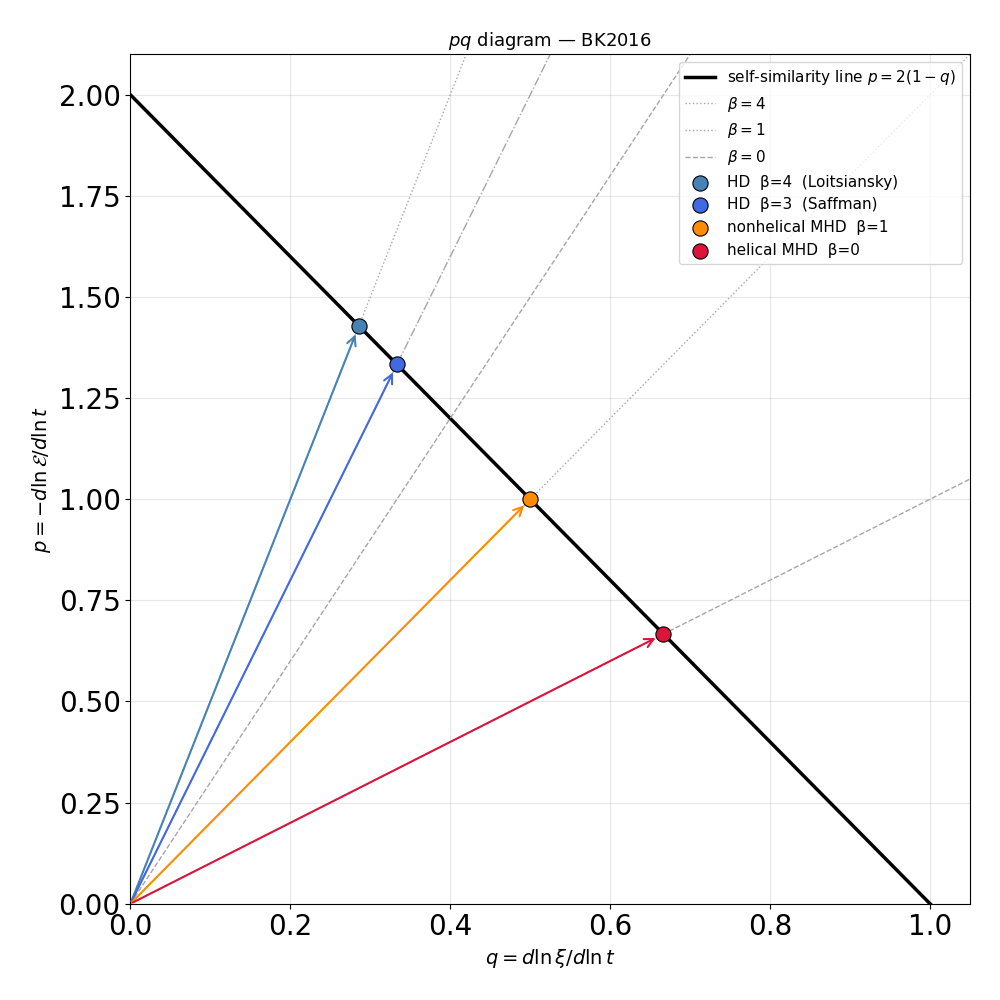

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

# ── self-similarity line  p = 2(1-q)  ─────────────────────────────────────
q_line = np.linspace(0.0, 1.1, 300)
p_ss   = 2.0 * (1.0 - q_line)
ax.plot(q_line, p_ss, 'k-', lw=2.5, label=r'self-similarity line $p=2(1-q)$', zorder=2)

# ── constant-beta lines  p = (1+beta)*q  ──────────────────────────────────
for beta_val, ls in [(4, ':'), (3, '-.'), (2, '--'), (1, ':'), (0, '--')]:
    q_b = np.linspace(0.0, 1.1, 200)
    p_b = (1 + beta_val) * q_b
    ax.plot(q_b, p_b, lw=1.0, ls=ls, color='0.65',
            label=fr'$\beta={beta_val}$' if beta_val in (4, 1, 0) else None)
    # label at q=0.9 or wherever in range
    q_label = 0.85
    p_label = (1 + beta_val) * q_label
    
# ── DNS fixed points ───────────────────────────────────────────────────────
for name, cls in CLASSES.items():
    q_fp = cls['q']
    p_fp = cls['p']
    ax.scatter([q_fp], [p_fp], s=120, color=cls['color'],
               zorder=5, edgecolors='k', lw=0.8, label=name)

    # schematic trajectory arrow: approach from higher p (lower q) along beta line
    q_start = q_fp * 0.0
    p_start = (1 + cls['beta']) * q_start
    dq = q_fp - q_start
    dp = p_fp - p_start
    ax.annotate('', xy=(q_fp - 0.01*dq, p_fp - 0.01*dp),
                xytext=(q_start, p_start),
                arrowprops=dict(arrowstyle='->', color=cls['color'],
                                lw=1.5, mutation_scale=16))

ax.set_xlim(0, 1.05)
ax.set_ylim(0, 2.1)
ax.set_xlabel(r'$q = d\ln\xi/d\ln t$', fontsize=14)
ax.set_ylabel(r'$p = -d\ln\mathcal{E}/d\ln t$', fontsize=14)
ax.set_title(r'$pq$ diagram — BK2016', fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Energy decay and integral-scale growth

The total energy $\mathcal{E}(t) \propto (1+t/t_1)^{-p}$ and integral scale $\xi(t) \propto (1+t/t_1)^{q}$
evolve as power laws once $t \gg t_1$.  The ratio $p/q = 1+\beta$ is the slope of the
constant-$\beta$ line in the $pq$ diagram.


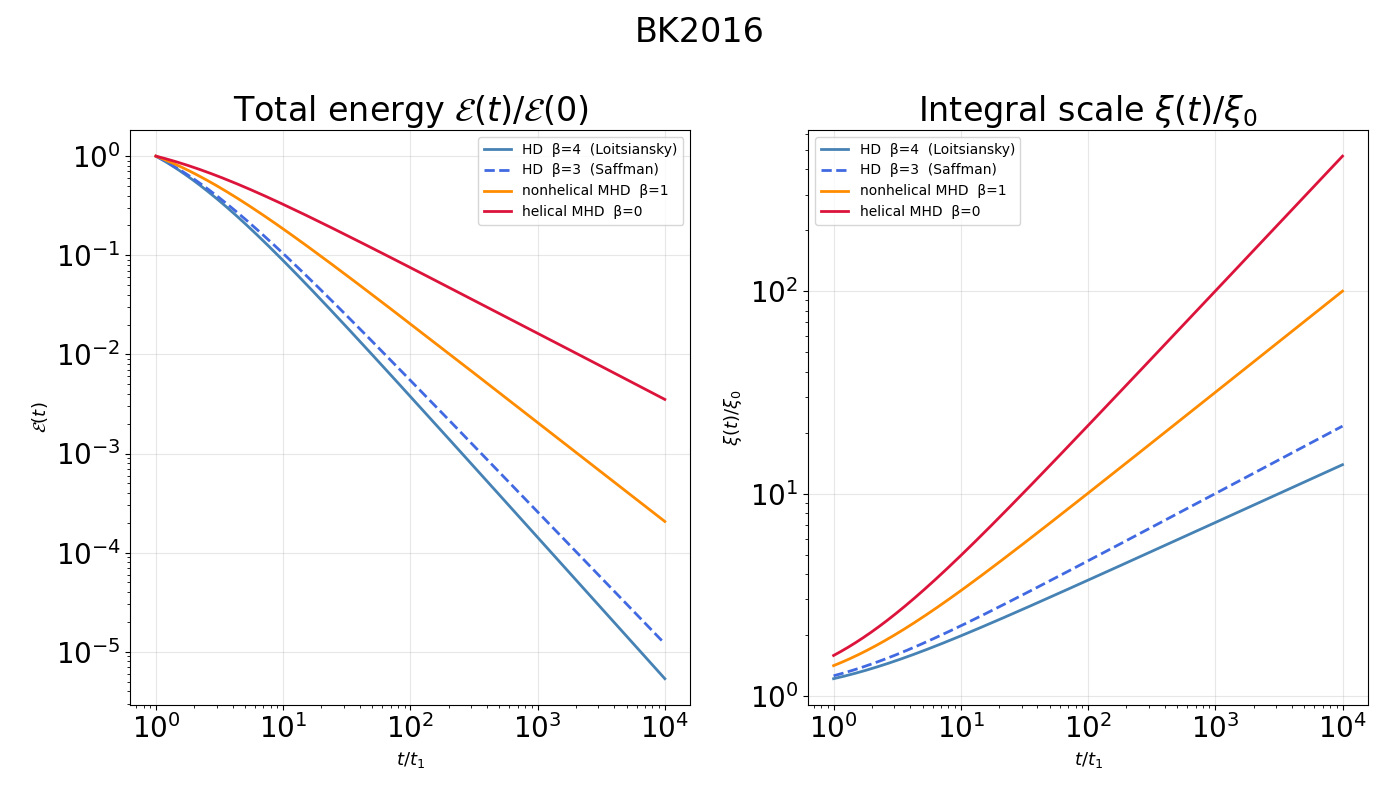

In [13]:
t_arr = np.logspace(0, 4, 4000)   # t/t1

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for name, cls in CLASSES.items():
    q_exp = cls['q']
    p_exp = cls['p']
    color = cls['color']
    ls    = cls['ls']

    # total energy from E_spectrum integrated over k_grid (numerical)
    E_total = np.array([
        np.trapezoid(E_spectrum(k_grid, t, cls['beta'], q_exp, k0_init=1.0, s=4), k_grid)
        for t in t_arr
    ])
    xi_arr = xi_t(t_arr, q_exp)   # integral scale normalised to xi(0)=1

    axes[0].loglog(t_arr, E_total / E_total[0], color=color, ls=ls, lw=2, label=name)
    axes[1].loglog(t_arr, xi_arr,                color=color, ls=ls, lw=2, label=name)

# reference power-law slopes
for ax, label, exp_dict, col in [
    (axes[0], r'$\mathcal{E}(t)$',
     {r'$t^{-p}$': {n: -CLASSES[n]['p'] for n in CLASSES}}, 'k'),
    (axes[1], r'$\xi(t)/\xi_0$',
     {r'$t^{q}$': {n:  CLASSES[n]['q'] for n in CLASSES}}, 'k'),
]:
    ax.set_xlabel(r'$t/t_1$', fontsize=13)
    ax.set_ylabel(label, fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title(r'Total energy $\mathcal{E}(t)/\mathcal{E}(0)$')
axes[1].set_title(r'Integral scale $\xi(t)/\xi_0$')

plt.suptitle('BK2016')
plt.tight_layout()
plt.show()


## Connection to gravitational-wave spectra

The turbulent source spectra explored above feed directly into the GW production
(computed in `src/gw_turbulence/core.py`).  The key link is:

$$\Omega_{\rm GW}(f) \propto \int_0^{f_{\rm peak}} \frac{dE_{\rm tur}}{d\ln k}\,\Pi(k)\,dk$$

where $\Pi(k)$ is the GW production efficiency kernel.
The shape of the turbulent source — specifically $\beta$ and $s$ — determines whether
the GW spectrum is rising, flat, or falling across the LISA / PTA frequency bands:

| Turbulence class |$\beta$ |
|---|---|
| helical MHD | 0 | 
| nonhelical MHD | 1 |
| HD Saffman | 3 | 
| HD Loitsiansky | 4 | 

The **inverse cascade** ($q>0$, peak moving to lower $k$) means the GW source is
active over a *broadening* range of frequencies as time progresses,
qualitatively unlike a stationary source.
